In [81]:
%load_ext autoreload
%autoreload 2

import os, sys
import matplotlib.pyplot as plt

sys.path.insert(0, "src")

from pandas import DataFrame
from analytics.metrics.metric import MetricCalculator
from analytics.metrics.time import TimeMetrics
from spec.enums import MainTableColumns as Cols
from spec.spec_definition import PS2Versions
import pandas as pd

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [135]:
from analytics.preprocessors.edwards import TimeStampToDateTimePreprocessor
from analytics.preprocessors.codebench import YAMLLinkURLPreprocessor
from analytics.ps2_dataset import SortPreprocessor

config_path = None
problem_id_col = None
timestamp_col = None
idle_gap = None
break_gap = None
proprocessing_steps = []
link_preprocessing_steps = []

edwards2021_config = {
    "config_path": "sample_data_configs/edwards2021.yaml",
    "problem_id_col": Cols.AssignmentID,
    "timestamp_col": Cols.ClientTimestamp,
    "idle_gap": 30,
    "break_gap": 3 * 60,
    "proprocessing_steps": [
        TimeStampToDateTimePreprocessor(),
        SortPreprocessor()
    ],
}

cwo_s19_config = {
    "config_path": "sample_data_configs/cwo_s19.yaml",
    "problem_id_col": Cols.ProblemID,
    "timestamp_col": Cols.ServerTimestamp,
    "idle_gap": 5 * 60,
    "break_gap": 30 * 60,
    "proprocessing_steps": [
        SortPreprocessor()
    ],
}

cwo_f19_config = {
    "config_path": "sample_data_configs/cwo_f19.yaml",
    "problem_id_col": Cols.ProblemID,
    "timestamp_col": Cols.ServerTimestamp,
    "idle_gap": 5 * 60,
    "break_gap": 30 * 60,
    "proprocessing_steps": [
        SortPreprocessor()
    ],
}

codebench2024_config = {
    "config_path": "sample_data_configs/codebench2024.yaml",
    "problem_id_col": Cols.ProblemID,
    "timestamp_col": Cols.ServerTimestamp,
    "idle_gap": 30,
    "break_gap": 3 * 60,
    "link_preprocessing_steps": [YAMLLinkURLPreprocessor(True)],

}

# config = codebench2024_config
# config = cwo_s19_config
config = cwo_f19_config
locals().update(config)

In [136]:
from database.config import PS2DataConfig

spec = PS2Versions.v1_0.load()

data_config = PS2DataConfig.from_yaml(config_path, spec)


In [137]:
from analytics.ps2_dataset import PS2Dataset

dataset = PS2Dataset(spec, data_config)
for i, step in enumerate(proprocessing_steps):
    dataset.main_table_preprocessors.insert(i, step)
for i, step in enumerate(link_preprocessing_steps):
    dataset.link_table_preprocessors.insert(i, step)

In [138]:
main_table = dataset.get_main_table()
main_table.head()

,SubjectID,ToolInstances,ServerTimestamp,ServerTimezone,CourseID,AssignmentID,ProblemID,Attempt,CodeStateID,IsEventOrderingConsistent,EventType,Score,Compile.Result,CompileMessageType,CompileMessageData,EventID,Order,ParentEventID
0,fd8111a7935742d5d198fb6ba2224bf1b772974b7c17e1...,Java 8; CodeWorkout,2019-09-23 15:14:44,0,CS 1,597,13,1,e03c3817ba234c667140a5281960bfc79238ef075b48c7...,True,Run.Program,0.0,NaN,NaN,NaN,0,0,NaN
1,fd8111a7935742d5d198fb6ba2224bf1b772974b7c17e1...,Java 8; CodeWorkout,2019-09-23 15:14:44,0,CS 1,597,13,1,e03c3817ba234c667140a5281960bfc79238ef075b48c7...,True,Compile,NaN,Error,NaN,NaN,1,1,0.0
2,fd8111a7935742d5d198fb6ba2224bf1b772974b7c17e1...,Java 8; CodeWorkout,2019-09-23 15:14:44,0,CS 1,597,13,1,e03c3817ba234c667140a5281960bfc79238ef075b48c7...,True,Compile.Error,NaN,NaN,SyntaxError,line 18: error: missing return statement,2,2,1.0
3,fd8111a7935742d5d198fb6ba2224bf1b772974b7c17e1...,Java 8; CodeWorkout,2019-09-23 15:15:13,0,CS 1,597,13,2,cdfe99579672f04db808aa7343826bf3c71751dfba129d...,True,Run.Program,0.0,NaN,NaN,NaN,3,3,NaN
4,fd8111a7935742d5d198fb6ba2224bf1b772974b7c17e1...,Java 8; CodeWorkout,2019-09-23 15:15:13,0,CS 1,597,13,2,cdfe99579672f04db808aa7343826bf3c71751dfba129d...,True,Compile,NaN,Error,NaN,NaN,4,4,3.0


AssignmentID
597    Axes(0.125,0.11;0.775x0.77)
600    Axes(0.125,0.11;0.775x0.77)
609    Axes(0.125,0.11;0.775x0.77)
615    Axes(0.125,0.11;0.775x0.77)
622    Axes(0.125,0.11;0.775x0.77)
631    Axes(0.125,0.11;0.775x0.77)
Name: ServerTimestamp, dtype: object

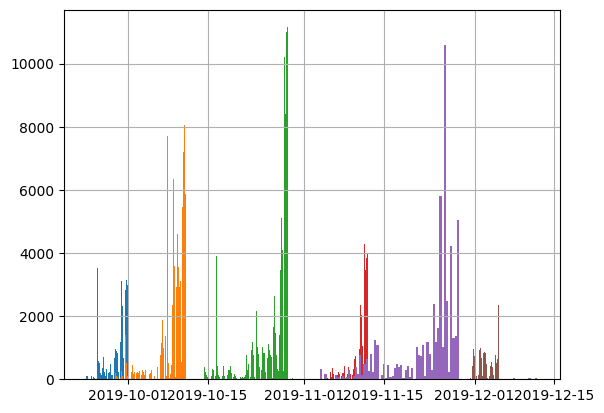

In [141]:
main_table.groupby(Cols.AssignmentID)[Cols.ServerTimestamp].hist(bins=100)

In [140]:
import numpy as np
for i in main_table[Cols.ServerTimestamp].quantile(np.arange(0, 1.01, 0.01)).to_list():
    print(i)

2019-09-23 15:14:44
2019-09-25 14:38:38
2019-09-25 18:39:32
2019-09-26 16:14:31
2019-09-27 20:37:48.800000
2019-09-28 21:02:42
2019-09-29 04:44:09.180000
2019-09-29 18:59:35.330000128
2019-09-29 21:21:43.160000
2019-09-30 00:30:44
2019-09-30 02:56:05
2019-09-30 13:17:34
2019-09-30 13:52:49
2019-09-30 15:50:50
2019-09-30 17:51:49
2019-09-30 19:50:43
2019-09-30 22:16:33
2019-10-01 00:51:45
2019-10-01 02:09:37.180000
2019-10-01 03:50:43.840000
2019-10-05 03:07:07.600000
2019-10-07 02:15:21
2019-10-07 20:22:20.140000
2019-10-07 22:29:51
2019-10-08 00:48:04
2019-10-08 03:19:28
2019-10-08 23:01:21.360000
2019-10-09 01:26:35.950000128
2019-10-09 04:07:07
2019-10-09 14:25:46
2019-10-09 18:05:00.900000
2019-10-09 23:26:17
2019-10-10 03:34:03.520000
2019-10-10 15:32:03.610000128
2019-10-10 18:06:37
2019-10-10 20:31:46.949999872
2019-10-10 22:41:35.560000
2019-10-11 00:36:37
2019-10-11 02:22:26
2019-10-14 08:20:59.490000128
2019-10-16 14:54:27
2019-10-19 03:44:19.460000
2019-10-22 22:13:06
2019-1

In [147]:
#get the data of the third quantile
max = main_table[Cols.ServerTimestamp].max()
min = main_table[Cols.ServerTimestamp].min()
range = max - min
# time_cutoff = min + range * 0.33 # S19
time_cutoff = min + range * 0.25 # F19
print(time_cutoff)
print(main_table[Cols.ServerTimestamp].min())
print(main_table[Cols.ServerTimestamp].max())

data_subset = main_table[main_table[Cols.ServerTimestamp] <= time_cutoff]
print("Assignment IDs:", data_subset[Cols.AssignmentID].unique())
print("Problem IDs:", data_subset[Cols.ProblemID].unique())
print("Total number of rows:", len(data_subset))
# Assignment IDs: [597 600]
# Problem IDs: [13 232 235 234 236   5 233   1   3  12  24 100 101  25 102  28  21  20  17  22]

2019-10-13 11:22:43
2019-09-23 15:14:44
2019-12-11 23:46:40
Assignment IDs: [597 600]
Problem IDs: [ 13 232 235 234 236   5 233   1   3  12  24 100 101 102  25  28  21  20
  17  22]
Total number of rows: 161703


In [148]:
student_subset = data_subset[Cols.SubjectID].unique()[:50]
mt_subset = data_subset[data_subset[Cols.SubjectID].isin(student_subset)]

In [149]:
grouping_cols = [Cols.SubjectID, problem_id_col]

<Axes: ylabel='Frequency'>

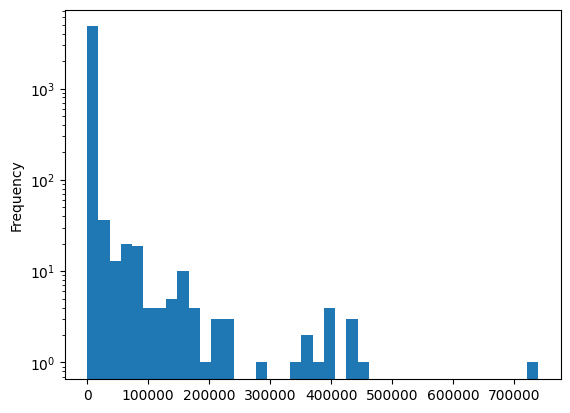

In [150]:
from analytics.metrics.time import TimeMetrics


diffs = TimeMetrics.get_all_diffs(mt_subset, timestamp_col, grouping_cols)
diffs.DeltaSeconds[diffs.DeltaSeconds > 0].plot.hist(bins=40, log=True)

In [151]:
TimeMetrics.get_positive_diff_quantiles(data_subset, timestamp_col, grouping_cols) / 60

# Seems like 5 minutes (90th+ percentile) is a good cutoff for time spent on a problem between submissions
# 30m does seem to suggest that the student is not working on the problem

0.00        0.016667
0.25        0.283333
0.50        0.600000
0.75        1.500000
0.80        1.916667
0.85        2.650000
0.90        4.370000
0.95       16.566667
0.96       35.628667
0.97      107.347667
0.98      450.717333
0.99     1357.943000
1.00    15148.533333
Name: DeltaSeconds, dtype: float64

In [152]:
time_metrics = TimeMetrics(idle_gap, break_gap, True, timestamp_col)

result = data_subset.groupby(grouping_cols).apply(lambda x: time_metrics.calculate(x))
result

C:\Users\twprice\AppData\Local\Temp\ipykernel_2992\3690036271.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  result = data_subset.groupby(grouping_cols).apply(lambda x: time_metrics.calculate(x))


ActiveTime  \
SubjectID                                          ProblemID               
00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd467... 1                 0.0   
                                                   3                58.0   
                                                   5                40.0   
                                                   12                0.0   
                                                   13              455.0   
...                                                                  ...   
ffc3b91c3744d275e99f49e105f016732d694a76314d8cd... 232               0.0   
                                                   233               0.0   
                                                   234              16.0   
                                                   235               0.0   
                                                   236               9.0   

                                                              PassiveTime  \
SubjectID                                          ProblemID                
00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd467... 1                  0.0   
                                                   3                353.0   
                                                   5                  0.0   
                                                   12                 0.0   
                                                   13                 0.0   
...                                                                   ...   
ffc3b91c3744d275e99f49e105f016732d694a76314d8cd... 232                0.0   
                                                   233                0.0   
                                                   234                0.0   
                                                   235                0.0   
                                                   236                0.0   

                                                              TotalTime  \
SubjectID                                          ProblemID              
00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd467... 1                0.0   
                                                   3              411.0   
                                                   5               40.0   
                                                   12               0.0   
                                                   13             455.0   
...                                                                 ...   
ffc3b91c3744d275e99f49e105f016732d694a76314d8cd... 232              0.0   
                                                   233              0.0   
                                                   234             16.0   
                                                   235              0.0   
                                                   236              9.0   

                                                              ActiveTimeAfterCorrect  \
SubjectID                                          ProblemID                           
00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd467... 1                             0.0   
                                                   3                             0.0   
                                                   5                             0.0   
                                                   12                            0.0   
                                                   13                            0.0   
...                                                                              ...   
ffc3b91c3744d275e99f49e105f016732d694a76314d8cd... 232                           0.0   
                                                   233                           0.0   
                                                   234                           0.0   
                                                   235                           0.0   
                                       

In [153]:
result.describe()

,ActiveTime,PassiveTime,TotalTime,ActiveTimeAfterCorrect,#Breaks,StartTime,FirstCorrectTime,EndTime
count,9750.000000,9750.000000,9750.000000,9750.000000,9750.000000,9750,9274,9750
mean,203.361128,129.870769,333.231897,4.567487,0.173538,2019-10-03 22:38:15.066563840,2019-10-03 22:06:38.720832512,2019-10-04 02:17:45.430563840
min,0.000000,0.000000,0.000000,0.000000,0.000000,2019-09-23 15:14:44,2019-09-23 15:16:48,2019-09-23 15:16:48
25%,0.000000,0.000000,0.000000,0.000000,0.000000,2019-09-30 01:03:36.750000128,2019-09-30 00:59:29.750000128,2019-09-30 02:10:21.750000128
50%,49.000000,0.000000,53.000000,0.000000,0.000000,2019-10-01 02:06:19.500000,2019-10-01 01:56:52.500000,2019-10-01 02:25:50
75%,232.000000,0.000000,299.000000,0.000000,0.000000,2019-10-09 03:26:34.500000,2019-10-09 13:05:38,2019-10-09 14:23:02.249999872
max,10241.000000,6387.000000,16114.000000,2162.000000,8.000000,2019-10-11 03:57:44,2019-10-11 03:57:14,2019-10-11 03:58:55
std,395.408440,452.479555,740.575767,44.160455,0.580955,NaN,NaN,NaN


In [154]:
from analytics.metrics.score import SubmissionScoreMetrics
from spec.enums import EventType

score_metrics = SubmissionScoreMetrics(EventType.RunProgram)

subject_problem_score = data_subset.groupby(grouping_cols).apply(lambda x: score_metrics.calculate(x))


C:\Users\twprice\AppData\Local\Temp\ipykernel_2992\2502026517.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  subject_problem_score = data_subset.groupby(grouping_cols).apply(lambda x: score_metrics.calculate(x))


In [155]:
subject_problem_score.head()

Attempts  \
SubjectID                                          ProblemID             
00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd467... 1                 1   
                                                   3                 4   
                                                   5                 3   
                                                   12                1   
                                                   13                6   

                                                              FirstCorrect  \
SubjectID                                          ProblemID                 
00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd467... 1                  True   
                                                   3                 False   
                                                   5                 False   
                                                   12                 True   
                                                   13                False   

                                                              EverCorrect  \
SubjectID                                          ProblemID                
00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd467... 1                 True   
                                                   3                 True   
                                                   5                 True   
                                                   12                True   
                                                   13                True   

                                                              Attempted  \
SubjectID                                          ProblemID              
00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd467... 1               True   
                                                   3               True   
                                                   5               True   
                                                   12              True   
                                                   13              True   

                                                              MaxScore  \
SubjectID                                          ProblemID             
00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd467... 1               1.0   
                                                   3               1.0   
                                                   5               1.0   
                                                   12              1.0   
                                                   13              1.0   

                                                              MinScore  \
SubjectID                                          ProblemID             
00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd467... 1               1.0   
                                                   3               0.0   
                                                   5               0.0   
                                                   12              1.0   
                                                   13              0.0   

                                                              MeanScore  \
SubjectID                                          ProblemID              
00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd467... 1           1.000000   
                                                   3           0.593750   
                                                   5           0.333333   
                                                   12          1.000000   
                                                   13          0.166667   

                                                              TotalAttempts  
SubjectID                                          ProblemID                 
00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd467... 1                      1  
                                                   3                      4  
                                                   5  

In [156]:
subject_problem_score.describe()

,Attempts,MaxScore,MinScore,MeanScore,TotalAttempts
count,9750.000000,9750.000000,9750.000000,9750.000000,9750.000000
mean,5.276615,0.983690,0.392008,0.624930,5.406769
std,7.649605,0.097838,0.465592,0.318270,7.802417
min,1.000000,0.000000,0.000000,0.000000,1.000000
25%,1.000000,1.000000,0.000000,0.333333,1.000000
50%,3.000000,1.000000,0.000000,0.563797,3.000000
75%,6.000000,1.000000,1.000000,1.000000,6.000000
max,177.000000,1.000000,1.000000,1.000000,177.000000


In [157]:
all_features = pd.merge(
    result.reset_index(),
    subject_problem_score.reset_index(),
    on=grouping_cols,
    how="outer"
)
all_features.head()

,SubjectID,ProblemID,ActiveTime,PassiveTime,TotalTime,ActiveTimeAfterCorrect,#Breaks,StartTime,FirstCorrectTime,EndTime,Attempts,FirstCorrect,EverCorrect,Attempted,MaxScore,MinScore,MeanScore,TotalAttempts
0,00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...,1,0.0,0.0,0.0,0.0,0,2019-09-27 12:43:31,2019-09-27 12:43:31,2019-09-27 12:43:31,1,True,True,True,1.0,1.0,1.000000,1
1,00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...,3,58.0,353.0,411.0,0.0,0,2019-09-27 12:46:46,2019-09-27 12:53:37,2019-09-27 12:53:37,4,False,True,True,1.0,0.0,0.593750,4
2,00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...,5,40.0,0.0,40.0,0.0,0,2019-09-27 12:35:42,2019-09-27 12:36:22,2019-09-27 12:36:22,3,False,True,True,1.0,0.0,0.333333,3
3,00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...,12,0.0,0.0,0.0,0.0,0,2019-09-27 12:56:42,2019-09-27 12:56:42,2019-09-27 12:56:42,1,True,True,True,1.0,1.0,1.000000,1
4,00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...,13,455.0,0.0,455.0,0.0,0,2019-09-27 11:29:04,2019-09-27 11:36:39,2019-09-27 11:36:39,6,False,True,True,1.0,0.0,0.166667,6


In [158]:
all_features.isna().mean()

SubjectID                 0.000000
ProblemID                 0.000000
ActiveTime                0.000000
PassiveTime               0.000000
TotalTime                 0.000000
ActiveTimeAfterCorrect    0.000000
#Breaks                   0.000000
StartTime                 0.000000
FirstCorrectTime          0.048821
EndTime                   0.000000
Attempts                  0.000000
FirstCorrect              0.000000
EverCorrect               0.000000
Attempted                 0.000000
MaxScore                  0.000000
MinScore                  0.000000
MeanScore                 0.000000
TotalAttempts             0.000000
dtype: float64

In [159]:
all_features_z = all_features.copy()

time_cols = [
    TimeMetrics.START_TIME,
    TimeMetrics.FIRST_CORRECT_TIME,
    TimeMetrics.END_TIME,
]

all_features_z[time_cols] = all_features_z[time_cols].astype('int64') / 1e9
numeric_cols = all_features_z.select_dtypes(include=["number"]).columns
# remove the grouping columns from numeric_cols
numeric_cols = numeric_cols.difference(grouping_cols)
all_features_z[numeric_cols] = all_features_z.groupby(problem_id_col)[numeric_cols].transform(lambda x: (x - x.mean()) / (x.std() if x.std() > 0 else 1))


In [160]:
all_features_z.head()

,SubjectID,ProblemID,ActiveTime,PassiveTime,TotalTime,ActiveTimeAfterCorrect,#Breaks,StartTime,FirstCorrectTime,EndTime,Attempts,FirstCorrect,EverCorrect,Attempted,MaxScore,MinScore,MeanScore,TotalAttempts
0,00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...,1,-0.422458,-0.138063,-0.327935,-0.102645,-0.105237,-1.145783,0.090262,-1.151575,-0.516736,True,True,True,0.072733,0.961969,0.902587,-0.530196
1,00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...,3,-0.363577,0.740400,0.245968,-0.122164,-0.221600,-1.143365,0.231311,-1.185029,-0.124091,False,True,True,0.162548,-0.921859,-0.299511,-0.139827
2,00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...,5,-0.324830,-0.215893,-0.323338,-0.112926,-0.210769,-1.113588,0.143479,-1.158226,-0.144805,False,True,True,0.098558,-1.066737,-1.361377,-0.162036
3,00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...,12,-0.393429,-0.121747,-0.306273,-0.108324,-0.120263,-1.148554,0.063693,-1.174828,-0.456668,True,True,True,0.053923,0.803577,0.767098,-0.471177
4,00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...,13,0.187025,-0.401501,-0.161818,-0.174791,-0.432159,-0.661027,0.238626,-0.789055,-0.259386,False,True,True,0.150089,-0.499183,-0.849907,-0.279460


In [161]:
subject_means = all_features_z.drop(problem_id_col, axis=1).groupby(Cols.SubjectID).mean()
subject_means.head()

,ActiveTime,PassiveTime,TotalTime,ActiveTimeAfterCorrect,#Breaks,StartTime,FirstCorrectTime,EndTime,Attempts,FirstCorrect,EverCorrect,Attempted,MaxScore,MinScore,MeanScore,TotalAttempts
SubjectID,,,,,,,,,,,,,,,,
00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd4670206aa82503a575dc,-0.297464,0.183327,-0.027601,-0.127728,-0.289159,-0.635549,0.200934,-0.706975,-0.319508,0.400000,1.000000,1.0,0.155992,0.067097,0.070329,-0.333956
014604ba54339d4b1266cf78e125053a5ac11dd861ef3cc0b4ed777ed0e2af0a,-0.431143,-0.074818,-0.268796,-0.093847,0.948068,0.304204,0.201065,0.355880,-0.313053,0.400000,1.000000,1.0,0.155992,0.092238,0.144573,-0.300600
01e96e066eff2e82627dac0493737be2de9bd2f50d6d498bb6420906c7164c05,-0.222163,-0.026535,-0.125751,-0.122669,-0.278372,-0.227894,-0.404033,-0.277828,-0.219626,0.333333,0.833333,1.0,-0.127872,-0.043900,0.046962,-0.235674
03000c72d4dd6a4be44ffc175dec5d9a15a83a2f8073b08b27be1fb7638cc466,0.125571,0.439323,0.352662,0.046516,0.351336,-0.169989,0.064650,-0.127258,-0.020818,0.500000,0.950000,1.0,0.095526,0.597959,0.553948,0.014240
0461c96c9cc0058f709704605f24136f373ba4e9ac083a1157d0976f1b6e8419,0.316437,-0.225456,0.015194,-0.125199,0.089202,-2.419324,0.080201,-2.357032,-0.079148,0.157895,0.947368,1.0,0.067430,-0.042656,0.096680,-0.098390


In [162]:
subject_totals = all_features_z.drop(problem_id_col, axis=1).groupby(Cols.SubjectID).sum()
subject_totals.head()

,ActiveTime,PassiveTime,TotalTime,ActiveTimeAfterCorrect,#Breaks,StartTime,FirstCorrectTime,EndTime,Attempts,FirstCorrect,EverCorrect,Attempted,MaxScore,MinScore,MeanScore,TotalAttempts
SubjectID,,,,,,,,,,,,,,,,
00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd4670206aa82503a575dc,-5.949270,3.666547,-0.552026,-2.554559,-5.783176,-12.710979,4.018687,-14.139494,-6.390163,8,20,20,3.119846,1.341946,1.406585,-6.679112
014604ba54339d4b1266cf78e125053a5ac11dd861ef3cc0b4ed777ed0e2af0a,-8.622868,-1.496361,-5.375911,-1.876934,18.961353,6.084089,4.021296,7.117600,-6.261064,8,20,20,3.119846,1.844767,2.891450,-6.012003
01e96e066eff2e82627dac0493737be2de9bd2f50d6d498bb6420906c7164c05,-3.998939,-0.477628,-2.263522,-2.208047,-5.010698,-4.102084,-7.272590,-5.000907,-3.953277,6,15,18,-2.301694,-0.790200,0.845325,-4.242139
03000c72d4dd6a4be44ffc175dec5d9a15a83a2f8073b08b27be1fb7638cc466,2.511418,8.786464,7.053244,0.930318,7.026711,-3.399786,1.293008,-2.545156,-0.416369,10,19,20,1.910527,11.959171,11.078960,0.284807
0461c96c9cc0058f709704605f24136f373ba4e9ac083a1157d0976f1b6e8419,6.012307,-4.283657,0.288680,-2.378775,1.694845,-45.967163,1.523825,-44.783606,-1.503808,3,18,19,1.281171,-0.810455,1.836918,-1.869414


In [163]:
subject_features = pd.merge(
    subject_means.reset_index(),
    subject_totals.reset_index(),
    on=Cols.SubjectID,
    how="outer",
    suffixes=('_mean', '_sum')
)
subject_features.head()

,SubjectID,ActiveTime_mean,PassiveTime_mean,TotalTime_mean,ActiveTimeAfterCorrect_mean,#Breaks_mean,StartTime_mean,FirstCorrectTime_mean,EndTime_mean,Attempts_mean,...,FirstCorrectTime_sum,EndTime_sum,Attempts_sum,FirstCorrect_sum,EverCorrect_sum,Attempted_sum,MaxScore_sum,MinScore_sum,MeanScore_sum,TotalAttempts_sum
0,00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...,-0.297464,0.183327,-0.027601,-0.127728,-0.289159,-0.635549,0.200934,-0.706975,-0.319508,...,4.018687,-14.139494,-6.390163,8,20,20,3.119846,1.341946,1.406585,-6.679112
1,014604ba54339d4b1266cf78e125053a5ac11dd861ef3c...,-0.431143,-0.074818,-0.268796,-0.093847,0.948068,0.304204,0.201065,0.355880,-0.313053,...,4.021296,7.117600,-6.261064,8,20,20,3.119846,1.844767,2.891450,-6.012003
2,01e96e066eff2e82627dac0493737be2de9bd2f50d6d49...,-0.222163,-0.026535,-0.125751,-0.122669,-0.278372,-0.227894,-0.404033,-0.277828,-0.219626,...,-7.272590,-5.000907,-3.953277,6,15,18,-2.301694,-0.790200,0.845325,-4.242139
3,03000c72d4dd6a4be44ffc175dec5d9a15a83a2f8073b0...,0.125571,0.439323,0.352662,0.046516,0.351336,-0.169989,0.064650,-0.127258,-0.020818,...,1.293008,-2.545156,-0.416369,10,19,20,1.910527,11.959171,11.078960,0.284807
4,0461c96c9cc0058f709704605f24136f373ba4e9ac083a...,0.316437,-0.225456,0.015194,-0.125199,0.089202,-2.419324,0.080201,-2.357032,-0.079148,...,1.523825,-44.783606,-1.503808,3,18,19,1.281171,-0.810455,1.836918,-1.869414


In [164]:
assert subject_features.isna().mean().mean() == 0

In [165]:
subject_feautres_z = subject_features.copy()
numeric_cols = subject_feautres_z.select_dtypes(include=["number"]).columns
subject_feautres_z[numeric_cols] = subject_feautres_z[numeric_cols].apply(lambda x: (x - x.mean()) / (x.std() if x.std() > 0 else 1), axis=0)
subject_feautres_z.head()

,SubjectID,ActiveTime_mean,PassiveTime_mean,TotalTime_mean,ActiveTimeAfterCorrect_mean,#Breaks_mean,StartTime_mean,FirstCorrectTime_mean,EndTime_mean,Attempts_mean,...,FirstCorrectTime_sum,EndTime_sum,Attempts_sum,FirstCorrect_sum,EverCorrect_sum,Attempted_sum,MaxScore_sum,MinScore_sum,MeanScore_sum,TotalAttempts_sum
0,00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...,-0.681976,0.487998,-0.073142,-0.350969,-0.674883,-0.804204,0.394493,-0.887989,-0.681731,...,0.485878,-0.900034,-0.711357,0.461610,0.513218,0.288621,0.379840,0.153132,0.154288,-0.742688
1,014604ba54339d4b1266cf78e125053a5ac11dd861ef3c...,-0.987288,-0.215226,-0.642284,-0.260234,2.242589,0.362448,0.394703,0.423574,-0.667995,...,0.486194,0.453063,-0.696985,0.461610,0.513218,0.288621,0.379840,0.210509,0.317162,-0.668508
2,01e96e066eff2e82627dac0493737be2de9bd2f50d6d49...,-0.509997,-0.083696,-0.304745,-0.337422,-0.649447,-0.298122,-0.583139,-0.358422,-0.469185,...,-0.879290,-0.318327,-0.440081,-0.025004,-1.021582,-0.500796,-0.280230,-0.090171,0.092723,-0.471707
3,03000c72d4dd6a4be44ffc175dec5d9a15a83a2f8073b0...,0.284194,1.185366,0.824161,0.115663,0.835450,-0.226237,0.174257,-0.172618,-0.046126,...,0.156331,-0.162009,-0.046350,0.948224,0.206258,0.288621,0.232606,1.364680,1.215246,0.031669
4,0461c96c9cc0058f709704605f24136f373ba4e9ac083a...,0.720114,-0.625583,0.027841,-0.344196,0.217321,-3.018662,0.199387,-2.924160,-0.170250,...,0.184238,-2.850652,-0.167405,-0.754925,-0.100702,-0.106088,0.155982,-0.092482,0.201491,-0.207871


In [ ]:
grades = dataset.get_link_table("Subject")
grades.head()

,SubjectID,X-Grade
0,80b79645be384d8162597a76b28062cd35ea1019db9344...,48.50
1,f2c0c481d6d6af0b83c418cd9a25d31dc1ffd303019b7c...,87.15
2,c24802aafcbbb5d0d9f4ff58778800955e3c56280ac703...,44.00
3,b83f22b6c073f282fc8e9556f47e3cb0ecb74d95097383...,52.03
4,fa57bd66cb6354a6d8af1e7b47b28589e586bf1303a908...,48.00


In [168]:
grade_col = "X-Grade"
grades.rename(columns={grade_col: "Grade"}, inplace=True)

# CWO only: drop 0 grades
print(f"Dropping {grades[grades['Grade'] <= 0].shape[0]} rows with 0 grades")
grades = grades[grades["Grade"] > 0]

Dropping 12 rows with 0 grades


In [169]:
subject_feautres_labeled = pd.merge(
    subject_feautres_z,
    grades,
    on=Cols.SubjectID,
    how="inner",
)

In [170]:
subject_feautres_labeled.head()

,SubjectID,ActiveTime_mean,PassiveTime_mean,TotalTime_mean,ActiveTimeAfterCorrect_mean,#Breaks_mean,StartTime_mean,FirstCorrectTime_mean,EndTime_mean,Attempts_mean,...,EndTime_sum,Attempts_sum,FirstCorrect_sum,EverCorrect_sum,Attempted_sum,MaxScore_sum,MinScore_sum,MeanScore_sum,TotalAttempts_sum,Grade
0,00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...,-0.681976,0.487998,-0.073142,-0.350969,-0.674883,-0.804204,0.394493,-0.887989,-0.681731,...,-0.900034,-0.711357,0.461610,0.513218,0.288621,0.379840,0.153132,0.154288,-0.742688,59.38
1,014604ba54339d4b1266cf78e125053a5ac11dd861ef3c...,-0.987288,-0.215226,-0.642284,-0.260234,2.242589,0.362448,0.394703,0.423574,-0.667995,...,0.453063,-0.696985,0.461610,0.513218,0.288621,0.379840,0.210509,0.317162,-0.668508,97.00
2,01e96e066eff2e82627dac0493737be2de9bd2f50d6d49...,-0.509997,-0.083696,-0.304745,-0.337422,-0.649447,-0.298122,-0.583139,-0.358422,-0.469185,...,-0.318327,-0.440081,-0.025004,-1.021582,-0.500796,-0.280230,-0.090171,0.092723,-0.471707,59.46
3,03000c72d4dd6a4be44ffc175dec5d9a15a83a2f8073b0...,0.284194,1.185366,0.824161,0.115663,0.835450,-0.226237,0.174257,-0.172618,-0.046126,...,-0.162009,-0.046350,0.948224,0.206258,0.288621,0.232606,1.364680,1.215246,0.031669,73.05
4,0461c96c9cc0058f709704605f24136f373ba4e9ac083a...,0.720114,-0.625583,0.027841,-0.344196,0.217321,-3.018662,0.199387,-2.924160,-0.170250,...,-2.850652,-0.167405,-0.754925,-0.100702,-0.106088,0.155982,-0.092482,0.201491,-0.207871,73.13


In [171]:
print(len(subject_feautres_labeled))
dir = os.path.join(dataset.data_config.root_path, "analysis")
if not os.path.exists(dir):
    os.makedirs(dir)
subject_feautres_labeled.to_csv(os.path.join(dir, "subject_features.csv"), index=False)

494
